Welcome to the EPISOL Colab Playground!



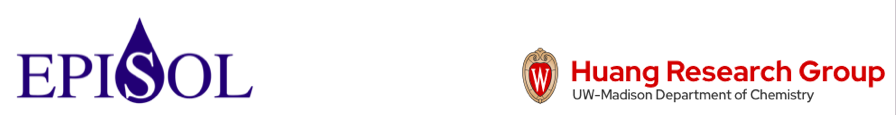

The 3D reference interaction site model (3DRISM) provides an efficient grid-based solvation model to compute the structural and thermodynamic properties of solutes emersed in solvent. However, this solvent need not be aqueous, and can hypothetically be *any* molecule. In this notebook we will walk through a high-throughput calculation on the solvation free energy of a test set of small molecules, emersed in a common electrolyte solvent.  

* **goals**:
  * utilize an organic solvent
  * Generate the coordinate and topology files for our test set using RDKit and openFF
  * Perform high-throughput 3DRISM calculations to determine solvation free energy of 100 electrolyte molecules in the test set
  * Be able to perform similar calculations on your own molecules
    * use the colab-notebook to download and run calculations on your own molecules

In [ ]:
#@title ##Download and Install Episol
#@markdown ($\approx 2$min) Stable as of 07/01/25 eprism v1.2.6
%%capture
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
#%cd ../home/
%cd $HOME/
%mkdir episol
%cd episol
!wget https://github.com/EPISOLrelease/EPISOL/raw/refs/heads/main/src/fftw/fftw-3.3.8.tar.gz
!echo "+++++++++++++++++++"
!echo "downloaded fftw files"
!echo "+++++++++++++++++++"
!tar -xzf fftw-3.3.8.tar.gz
%cd fftw-3.3.8/
#!./configure --prefix=/home/fftw-3.3.8
!./configure --prefix=$HOME/episol/fftw-3.3.8
!make
!make install
%cd ../
!wget https://github.com/EPISOLrelease/EPISOL/raw/refs/heads/main/src/kernel/release.tar.gz
!echo "+++++++++++++++++++"
!echo "downloaded Episol files"
!echo "+++++++++++++++++++"
!tar -xzf release.tar.gz
%cd release/
#!./configure --with-fftw=/home/fftw-3.3.8
!./configure --with-fftw=$HOME/episol/fftw-3.3.8
!make
!make install
#%cd /content
########################### WRAPEPR
import subprocess
import os
import threading
import pandas as pd
import matplotlib.pyplot as plt
!pip install episol


In [ ]:
#@title Install some python packages for topology generation
#@markdown ($\approx$4min)

#@markdown This will prompt a restart in our colab session, this is necessary, just keep moving

#@markdown (if you are using the notebook offline this wont be necessary, as presumably you'll have your own forcefield to generate topologies)
########################################
#        FOR COLAB USERS ONLY          #
#---------------------------------------#
# if you are running locally you dont need
# condacolab. Just use your local conda dist
########################################
!pip install -q condacolab
import condacolab
condacolab.install()
########################################
#!conda update conda
#!conda install --yes -c conda-forge  python=3.11 numpy=1.26.4 openmm pdbfixer parmed mdanalysis py3dmol rdkit openff-toolkit
#!conda install -y -c conda-forge numpy=1.26.4 openmm=8.3.1 python={PYTHON_VERSION} pdbfixer=1.11 parmed=4.3.0 mdanalysis=2.9.0 py3dmol=2.5.2 rdkit=2025.03.5 openff-toolkit=0.17.0 libgcc
#!conda install -y -c conda-forge python=3.12 numpy=1.26.4 openmm=8.3.1 parmed=4.3.0 mdanalysis=2.9.0 py3dmol=2.5.2 rdkit=2025.03.5 openff-toolkit=0.17.0 torchvision
#openmm pdbfixer parmed mdanalysis py3dmol rdkitconda install libgcc

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


In [ ]:
%%capture
!python -m ensurepip --upgrade
!python3.12 -m pip install --upgrade setuptools
#!pip3 install scikit-learn
!conda install -y -c conda-forge python=3.12 numpy=1.26.4 openmm=8.3.1 pdbfixer=1.11 parmed=4.3.0 mdanalysis=2.9.0 py3dmol=2.5.2 rdkit=2025.03.5 openff-toolkit=0.17.0 torchvision pymol-open-source ambertools

In [ ]:
#@title import our download packages
%%capture
ias!!ddmport py3Dmol

def MolTo3DView(mol, size=(300, 300), style="stick", surface=False, opacity=0.5):
    """
    https://birdlet.github.io/2019/10/02/py3dmol_example/
    Draw molecule in 3D

    Args:
    ----
        mol: rdMol, molecule to show
        size: tuple(int, int), canvas size
        style: str, type of drawing molecule
               style can be 'line', 'stick', 'sphere', 'carton'
        surface, bool, display SAS
        opacity, float, opacity of surface, range 0.0-1.0
    Return:
    ----
        viewer: py3Dmol.view, a class for constructing embedded 3Dmol.js views in ipython notebooks.
    """
    assert style in ('line', 'stick', 'sphere', 'carton')
    mblock = Chem.MolToMolBlock(mol)
    viewer = py3Dmol.view(width=size[0], height=size[1])
    viewer.addModel(mblock, 'mol')
    viewer.setStyle({style:{}})
    if surface:
        viewer.addSurface(py3Dmol.SAS, {'opacity': opacity})
    viewer.zoomTo()
    return viewer
def smi2conf(smiles):
    '''Convert SMILES to rdkit.Mol with 3D coordinates'''
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        AllChem.MMFFOptimizeMolecule(mol, maxIters=200)
        return mol
    else:
        return None
#free_energy("EXP")
!python -m ensurepip --upgrade # since we are using python 3.12 some pkg utils are now obsolete
# after conda-initiate restart colab resets pip
import matplotlib.pyplot as plt
import openmm as mm
from   openmm import app
from   openmm.unit import *
import py3Dmol as pymol
import MDAnalysis as md
import parmed as chem
from openff.toolkit.topology import Molecule, Topology
import numpy as np
from MDAnalysis.transformations import center_in_box
# from episol import epipy
from rdkit import Chem
from rdkit.Chem import AllChem
from openff.toolkit.topology import Molecule
from openff.toolkit.utils import get_data_file_path
from openff.toolkit.typing.engines.smirnoff import ForceField
from openff.interchange import Interchange

# FIX IMPORTER ERROR
!python -m ensurepip --upgrade
!pip3 install episol
!python3.12 -m pip install --upgrade setuptools
%cd /content/

# Procedure

* To use a solvent besides water, we need bulk solvent-solvent correlations
* these can be acquired with MD or with 1DRISM
* here we will use a mixture of water and cyanide

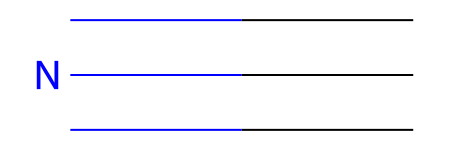

In [125]:
smi = "N#C"
mol = Chem.MolFromSmiles(smi)
mol

In [126]:
mol = Chem.rdmolops.AddHs(mol,addCoords=True)
AllChem.EmbedMolecule(mol)
AllChem.UFFOptimizeMolecule(mol)
MolTo3DView(mol).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.


$$$$
$$h(r)_i^{\rm sol.-solv.} = \rho\sum_j\int c(r)_j^{\rm sol.-solv.}\left[\omega(r)_j^{\rm solv.-solv.} + h(r)_j^{\rm solv.-solv.}\right]d\mathbf{r}$$


$$$$
$$
h(r)_i^{\rm sol.-solv.} \equiv \exp{\left( - U(r)_i^{\rm sol.-solv.} + h(r)_i^{\rm sol.-solv.}+ c(r)_i^{\rm sol.-solv.} + \mathfrak{B}\right)}
$$

$$$$

* we will download our correlations [here](https://github.com/p-swanson/solvents)

In [48]:
%%capture
!wget https://raw.githubusercontent.com/p-swanson/solvents/refs/heads/main/organic/cyanide.gvv
!wget https://raw.githubusercontent.com/p-swanson/solvents/refs/heads/main/organic/cyanide.sol


* we can see that we have a mixture of cyanide and water.
* this correspondings to 5 sites in total

* here we will test our system with the classic methane example

In [ ]:
!wget https://raw.githubusercontent.com/p-swanson/solvents/refs/heads/main/tests/methane.gro
!wget https://raw.githubusercontent.com/p-swanson/solvents/refs/heads/main/tests/methane.top

In [123]:
test = int()

In [124]:
mem = epipy("methane.gro","methane.top",gen_idc=True)
mem.closure = "KH"
mem.err_tol = 1e-04
mem.ndiis = 15
mem.solvent("cyanide.sol")
mem.solvent_path = "./"
mem.report(f"methane_cyanide_{mem.closure}")
mem.rism(step=2000,resolution=0.5)
mem.kernel(nt=2)
test +=1

converted methane.top to methane.solute
generated idc-enabled solute file to: idc_methane.solute
Calculation finished in 42 steps 
err_tol: 0.0001 actual: 9.96146e-05 


In [53]:
guv = mem.select_grid()

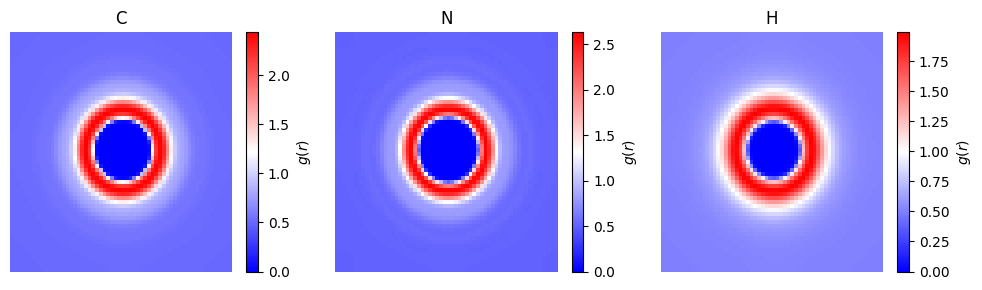

In [60]:
SLICE = 30
names = ["C","N","H"]
fig,axs = plt.subplots(1,3,figsize=(10,3))
for ind,(ax,name) in enumerate(zip(axs.flatten(),names)):
  # select values
  t = mem.reader(f"methane_cyanide_{mem.closure}.txt",atom_to_select=ind+3)
  p = ax.pcolormesh(t[SLICE],cmap='bwr')
  ax.set_title(name)
  fig.colorbar(p,ax=ax,label="$g(r)$")
  ax.set_axis_off()
fig.tight_layout()